## Import Libraries and dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_csv("../data/pasig_clean_for_model.csv")

In [5]:
df.head()

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month,apparent_temperature_max,datetime
0,26.3,22.8,16.80,40601.74,36354.61,3.60,3.0,3.0,18.5,56.2,1,34.1,2020-01-01
1,26.7,22.9,19.18,40613.83,36596.39,4.24,0.1,0.1,15.6,51.1,1,34.3,2020-01-02
2,25.8,21.8,19.77,40626.99,36371.84,4.38,0.0,0.0,17.6,39.2,1,32.6,2020-01-03
3,25.5,20.8,18.11,40641.20,36672.16,4.04,0.0,0.0,16.3,37.1,1,33.4,2020-01-04
4,26.1,22.7,19.31,40656.43,36598.13,4.50,0.0,0.0,21.3,46.4,1,31.1,2020-01-05


## Features and Target

In [6]:
features = [
    'temperature_2m_mean',
    'temperature_2m_min',
    'shortwave_radiation_sum',
    'daylight_duration',
    'sunshine_duration',
    'et0_fao_evapotranspiration',
    'rain_sum',
    'precipitation_sum',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'month'
]

target = 'apparent_temperature_max'

In [7]:
x = df[features]
x.head()

,temperature_2m_mean,temperature_2m_min,shortwave_radiation_sum,daylight_duration,sunshine_duration,et0_fao_evapotranspiration,rain_sum,precipitation_sum,wind_speed_10m_max,wind_gusts_10m_max,month
0,26.3,22.8,16.80,40601.74,36354.61,3.60,3.0,3.0,18.5,56.2,1
1,26.7,22.9,19.18,40613.83,36596.39,4.24,0.1,0.1,15.6,51.1,1
2,25.8,21.8,19.77,40626.99,36371.84,4.38,0.0,0.0,17.6,39.2,1
3,25.5,20.8,18.11,40641.20,36672.16,4.04,0.0,0.0,16.3,37.1,1
4,26.1,22.7,19.31,40656.43,36598.13,4.50,0.0,0.0,21.3,46.4,1


In [8]:
y = df[target]
y.head()

0    34.1
1    34.3
2    32.6
3    33.4
4    31.1
Name: apparent_temperature_max, dtype: float64

## Train/Test Split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((1533, 11), (384, 11))

## Feature Scaling

In [10]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Function to evaluate models

In [18]:
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"---{name}---")
    print("MSE :", mse)
    print("MAE :", mae)
    print("R2 :", r2)

    return {"model": name, "MSE": mse, "MAE": mae, "R2": r2}

In [26]:
results = []

## Model

### Linear Regression

In [27]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)

results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))

---Linear Regression---
MSE : 1.0838318641487554
MAE : 0.7830909573036718
R2 : 0.8615132580547828


### Polynomial Regression

In [28]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

poly_lr = LinearRegression()
poly_lr.fit(x_train_poly, y_train)

y_pred_poly = poly_lr.predict(x_test_poly)

results.append(evaluate_model("Polynomial Regression (deg=2)", y_test, y_pred_poly))

---Polynomial Regression (deg=2)---
MSE : 0.834347592597006
MAE : 0.7006558490290224
R2 : 0.893391139741638


### Support Vector Regression

In [29]:
svr = SVR(kernel='rbf')
svr.fit(x_train_scaled, y_train)

y_pred_svr = svr.predict(x_test_scaled)
results.append(evaluate_model("SVR (RBF)", y_test, y_pred_svr))

---SVR (RBF)---
MSE : 0.9273166574972063
MAE : 0.7216919894843402
R2 : 0.8815120067085506


### KNN Regressor

In [30]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

y_pred_knn = knn.predict(x_test_scaled)

results.append(evaluate_model("KNN Regressor (k=5)", y_test, y_pred_knn))

---KNN Regressor (k=5)---
MSE : 1.1938087417807484
MAE : 0.8426887613082813
R2 : 0.8474609497804506


### Decision Tree Regressor

In [31]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(x_train, y_train)   # NO scaling needed

y_pred_tree = tree.predict(x_test)

results.append(evaluate_model("Decision Tree", y_test, y_pred_tree))

---Decision Tree---
MSE : 1.8922363708153718
MAE : 1.0926594032707024
R2 : 0.7582192786052872


### Random Forest Regressor

In [32]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf.fit(x_train, y_train)     # NO scaling needed

y_pred_rf = rf.predict(x_test)

results.append(evaluate_model("Random Forest", y_test, y_pred_rf))

---Random Forest---
MSE : 0.8543713154354157
MAE : 0.7239915785925536
R2 : 0.8908326062372892


## Model Performance

In [33]:
df_results = pd.DataFrame(results)
df_results

,model,MSE,MAE,R2
0,Linear Regression,1.083832,0.783091,0.861513
1,Polynomial Regression (deg=2),0.834348,0.700656,0.893391
2,SVR (RBF),0.927317,0.721692,0.881512
3,KNN Regressor (k=5),1.193809,0.842689,0.847461
4,Decision Tree,1.892236,1.092659,0.758219
5,Random Forest,0.854371,0.723992,0.890833


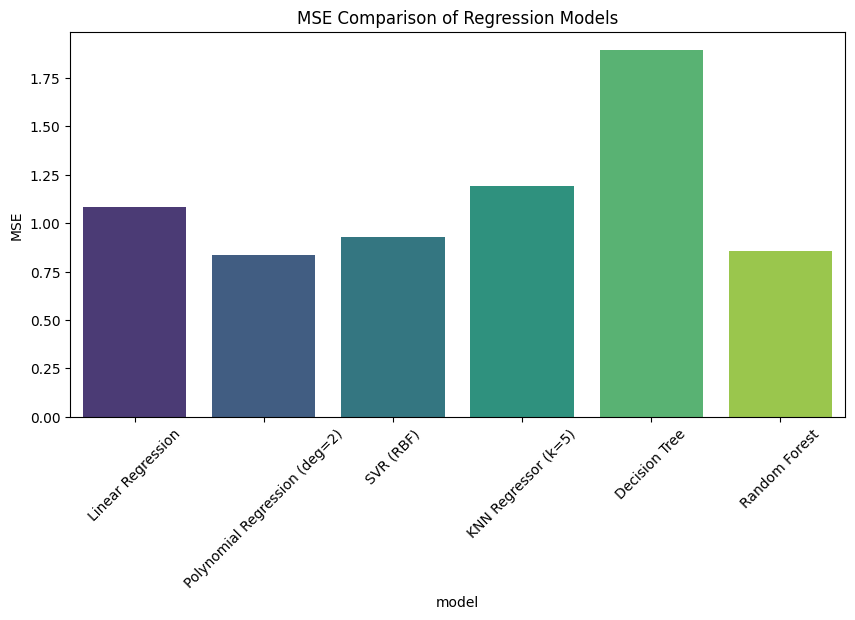

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="model", y="MSE", hue = "model", palette ="viridis")
plt.xticks(rotation=45)
plt.title("MSE Comparison of Regression Models")
plt.show()

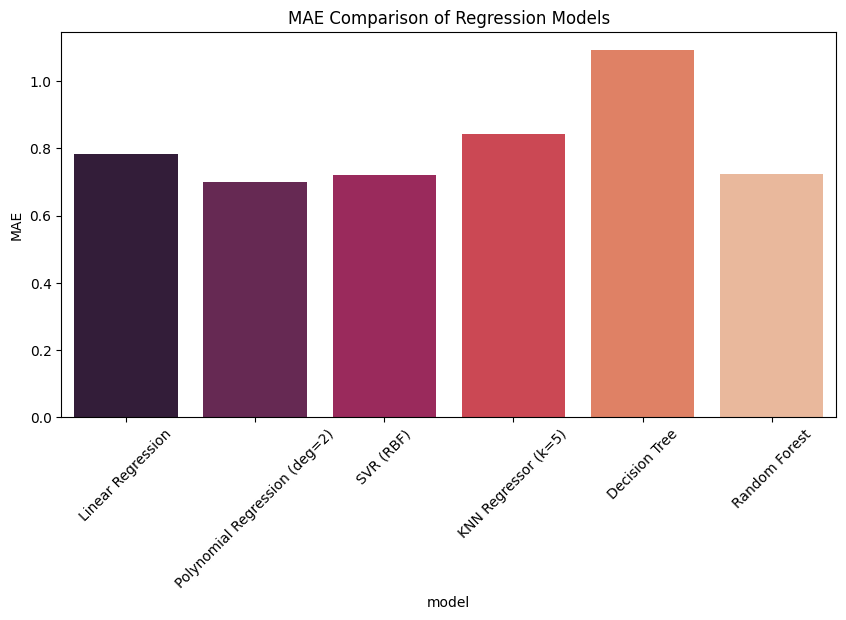

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="model", y="MAE", hue = "model", palette="rocket")
plt.xticks(rotation=45)
plt.title("MAE Comparison of Regression Models")
plt.show()


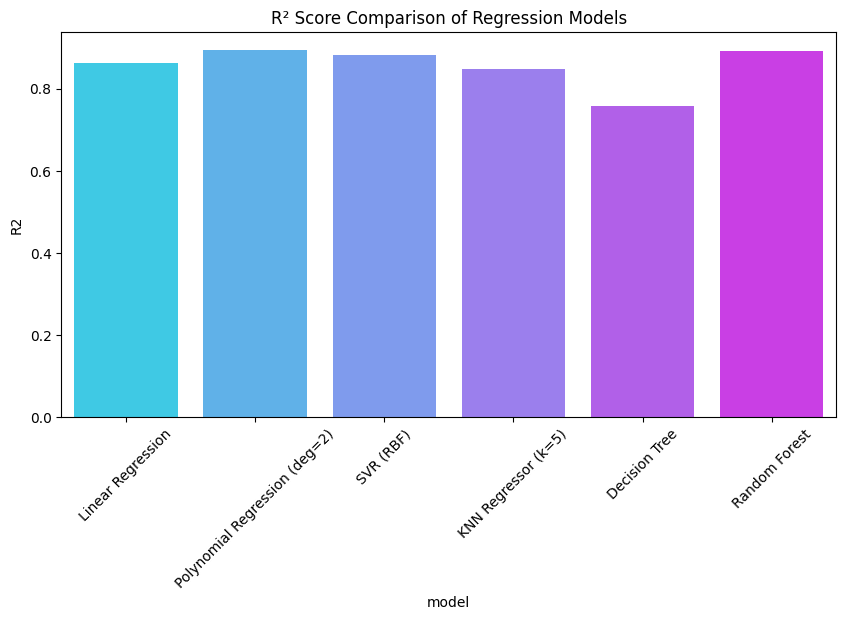

In [37]:
plt.figure(figsize=(10,5))
sns.barplot(data=df_results, x="model", y="R2", hue="model", palette="cool")
plt.xticks(rotation=45)
plt.title("R² Score Comparison of Regression Models")
plt.show()

In [38]:
df_results.sort_values("R2", ascending=False)

,model,MSE,MAE,R2
1,Polynomial Regression (deg=2),0.834348,0.700656,0.893391
5,Random Forest,0.854371,0.723992,0.890833
2,SVR (RBF),0.927317,0.721692,0.881512
0,Linear Regression,1.083832,0.783091,0.861513
3,KNN Regressor (k=5),1.193809,0.842689,0.847461
4,Decision Tree,1.892236,1.092659,0.758219


Interpretation

MAE ≈ 0.70–0.85
On average, your models are off by less than 1°C. That’s very good for weather-style data.

R² between 0.85–0.89 for top models
→ 85–89% of the variation in apparent_temperature_max is explained by your features. Also very solid.

Which model is “best”?

Formally (by R²) →
Polynomial Regression (deg=2) is the top:

Highest R² (0.893)

Lowest MSE and MAE

Practically / For deployment →
I will consider Random Forest as my “production” model because:
- Performance is almost identical (R² 0.891 vs 0.893 — basically a tie)
- Tree ensembles like Random Forest are:
- more robust to noise
- less sensitive to scaling
- easier to use (no need to store scaler + polynomial transformer)
- handle nonlinearities naturally

### Save moodel for production

In [40]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

# create models folder
os.makedirs("../models", exist_ok=True)

rf_final = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_final.fit(x, y)

# Save model
model_path = "../models/rf_pasig_apparent_temp.pkl"
joblib.dump(rf_final, model_path)

print(f"Final Random Forest model saved to: {model_path}")

Final Random Forest model saved to: ../models/rf_pasig_apparent_temp.pkl


### Save feature list - Optional

In [42]:
import json

features = [
    'temperature_2m_mean',
    'temperature_2m_min',
    'shortwave_radiation_sum',
    'daylight_duration',
    'sunshine_duration',
    'et0_fao_evapotranspiration',
    'rain_sum',
    'precipitation_sum',
    'wind_speed_10m_max',
    'wind_gusts_10m_max',
    'month'
]

with open("../models/feature_list.json", "w") as f:
    json.dump(features, f)

print("Feature list saved.")


Feature list saved.
